# Testes de hipóteses paramétricos

Os métodos paramétricos são aplicados para dados quantitativos e exigem suposições fortes para sua validação, incluindo:

- as observações devem ser independentes;
- a amostra deve ser retirada de populações com determinada distribuição, geralmente a normal;
- as populações devem ter variâncias iguais para testes de comparação de duas médias populacionais emparelhadas ou $k$ médias populacionais ($k \ge 3$);
- as variáveis em estudo devem ser medidas em escala intervalar ou de razão, do modo que seja possível utilizar operações aritméticas sobre os respectivos valores.

## Testes sobre uma média populacional ($\mu$) a partir de uma amostra aleatória

O objetivo é testar se uma média populacional assume ou não determinado valor

### Teste t de Student quando o desvio-padrão populacional ($\sigma$) não for conhecido

O teste *t* de *Student* para uma amostra é aplicado quando não conhecemos o desvio-padrão da população ($\sigma$), de modo que seu valor é estimado a partir do desvio-padrão da amostra ($S$), resultando na distribuição t de Student:


$$
T_{cal} = \frac{\bar{X} - \mu_0}{\frac{S}{\sqrt{n}}}
$$

Para um teste bilateral, as hipóteses são:

- $H_0$: a amostra provém de uma população com determinada média ($\mu = \mu_0$)
- $H_1$: contesta a hipótese nula ($\mu \neq \mu_0$)

Exemplo: O tempo médio de processamento de determinada tarefa em uma máquina tem sido de 18 minutos. Foram introduzidos novos conceitos para reduzir o tempo médio de processamento. Desta forma, após certo período, coletou-se uma amostra de 25 elementos (base a seguir). Verifique se o resultado evidencia uma melhora no tempo médio de processamento. Considere $\alpha = 1 \%$.

$H_1: \mu < 18$

In [1]:
import pandas as pd

BASE_TEMPO_MAQUINA = "./dados/tempo_maquina.csv"

df_tempo_maquina = pd.read_csv(BASE_TEMPO_MAQUINA)

df_tempo_maquina.head()

,tempo
0,21.5
1,16.0
2,15.4
3,9.5
4,16.7


In [2]:
df_tempo_maquina.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tempo   25 non-null     float64
dtypes: float64(1)
memory usage: 332.0 bytes


In [3]:
df_tempo_maquina.describe()

,tempo
count,25.000000
mean,16.744000
std,2.797928
min,9.500000
25%,15.300000
50%,16.700000
75%,18.600000
max,21.500000


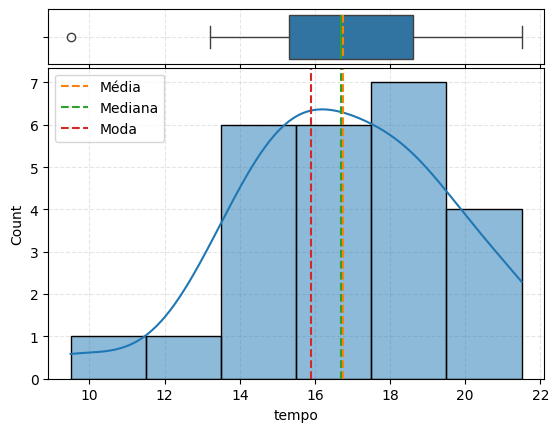

In [4]:
from auxiliares import composicao_histograma

composicao_histograma(df_tempo_maquina,"tempo")

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html

In [5]:
from auxiliares import analise_shapiro

analise_shapiro(df_tempo_maquina,alfa=0.01)


 

teste de shapiro
 estatistica_sw =0.970
tempo segue uma distribuição normal (valor p: 0.637)


In [7]:
from scipy.stats import ttest_1samp

ttest_1samp(df_tempo_maquina['tempo'], 18, alternative='less')

TtestResult(statistic=np.float64(-2.244518242956968), pvalue=np.float64(0.017143135109538046), df=np.int64(24))

Como p > 0.01, não rejeitamos a hipótese nula. Concluindo que, ao nível de confiança de 99 %, não houve melhora no tempo médio de processamento.

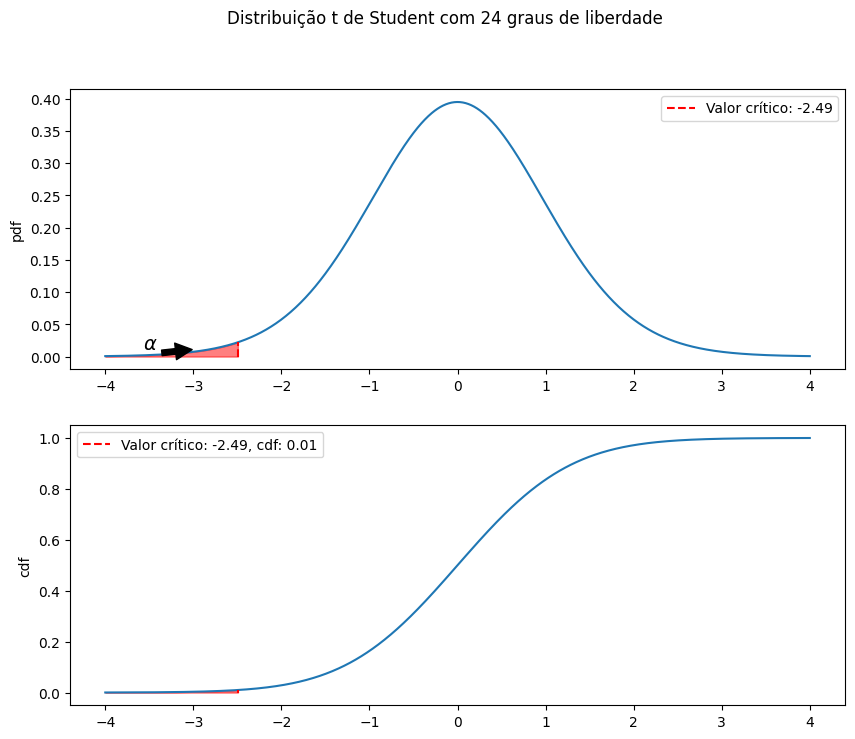

In [10]:
from graficos import plot_t_student

plot_t_student(24, 0.01, lado="esquerda")